## Milestone 1: Analyze the dataset
#### Nana Noda-Morgan

In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (9,5)
plt.rcParams["axes.grid"] = True

data = pd.read_excel("nationaldatabaseofchildcareprices.xlsx", sheet_name="nationaldatabaseofchildcare")
codes = pd.read_excel("Codes.xlsx", sheet_name="Sheet1")

# Standardize columns
data.columns = [c.strip() for c in data.columns]
id_cols = [c for c in ["State_Name","State_Abbreviation","County_Name","County_FIPS_Code","StudyYear"] if c in data.columns]

print("Rows:", len(data), "Cols:", len(data.columns))
data[id_cols].head()

Rows: 34567 Cols: 227


,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear
0,Alabama,AL,Autauga County,1001,2008
1,Alabama,AL,Autauga County,1001,2009
2,Alabama,AL,Autauga County,1001,2010
3,Alabama,AL,Autauga County,1001,2011
4,Alabama,AL,Autauga County,1001,2012


In [6]:
# Quick Data Health Checks

#Duplicate check on (county, year)
if set(["County_FIPS_Code","StudyYear"]).issubset(data.columns):
    dups = data.duplicated(subset=["County_FIPS_Code","StudyYear"]).sum()
    print("Duplicate (FIPS,Year) rows:", dups)

#Find columns with most missing data
missing = data.isna().mean().sort_values(ascending=False).head(25)
print("Top missing columns:\n", missing)

#describe unemployment columns likely to exist
unemp_cols = [c for c in data.columns if re.fullmatch(r"(F|M)?UNR(_20to64)?", c)]
print("Unemployment cols found:", unemp_cols)
print(data[unemp_cols].describe().T if unemp_cols else "No unemployment columns found.")

Duplicate (FIPS,Year) rows: 0
Top missing columns:
 iMFCC12to17     0.324124
iMFCCBto5       0.324124
iMFCC54toSA     0.324124
iMFCC48to53     0.324124
iMFCC42to47     0.324124
iMFCC36to41     0.324124
iMFCC30to35     0.324124
iMFCC24to29     0.324124
iMFCC18to23     0.324124
iMFCC6to11      0.324124
iMFCCSA         0.324124
MFCC54toSA      0.323546
_75FCCSA        0.323546
MFCCBto5        0.323546
MFCC6to11       0.323546
MFCC12to17      0.323546
MFCC18to23      0.323546
MFCC24to29      0.323546
MFCC30to35      0.323546
MFCC36to41      0.323546
MFCC42to47      0.323546
MFCC48to53      0.323546
_75FCC54toSA    0.323546
MFCCSA          0.323546
_75FCC48to53    0.323546
dtype: float64
Unemployment cols found: ['UNR_20to64', 'FUNR_20to64', 'MUNR_20to64']
               count      mean       std  min  25%  50%   75%   max
UNR_20to64   34567.0  6.900073  3.446199  0.0  4.6  6.5  8.70  33.9
FUNR_20to64  34567.0  6.482007  3.477956  0.0  4.2  6.0  8.25  44.5
MUNR_20to64  34567.0  7.275457  3.

Results above show that:  

- No duplicate county-year rows.  
- 32% concentrated in the iMFCC age-range columns. These are fine-grained family-child-care buckets that aren't reported in many county-years. (Not the best for trend charts)  
- Unemployment coverage is good (UNR_20to64, FUNR_20to64, MUN_20to64) for about 34.5k rows. Medians around 6-7% which is a good signal for workforce tie-ins.  

In [11]:
def coverage_by_year(df, cols, year_col="StudyYear", threshold=0.8):
    out = []
    for c in cols:
        if c not in df.columns: 
            continue
        cov = df.groupby(year_col)[c].apply(lambda s: s.notna().mean()).rename("coverage")
        yrs_ok = (cov >= threshold).sum()
        out.append({"column": c, "years_ok": int(yrs_ok), "mean_coverage": float(cov.mean())})
    return (pd.DataFrame(out)
              .sort_values(["years_ok","mean_coverage"], ascending=False))

#candidate childcare price columns:
price_candidates = [c for c in data.columns 
                    if re.fullmatch(r"(MCCC|MFCC)(Infant|Toddler|Preschool)", c)]

cov_table = coverage_by_year(data, price_candidates, threshold=0.85)
print(cov_table)

#keep the top 3–6 with the best coverage
keep_price_cols = cov_table["column"].head(6).tolist()
print("Keeping price columns:", keep_price_cols)

          column  years_ok  mean_coverage
0     MFCCInfant         0       0.676461
1    MFCCToddler         0       0.676461
2  MFCCPreschool         0       0.676461
Keeping price columns: ['MFCCInfant', 'MFCCToddler', 'MFCCPreschool']


In [15]:
#drop fine-grained bucket columns
sparse_patterns = (r"^iMFCC", r"_75FCC\d+to\d+", r"MFCC\d+to\d+", r"MCCC\d+to\d+")
drop_cols = [c for pat in sparse_patterns for c in data.columns if re.match(pat, c)]
print("Dropping bucketed/sparse cols from analysis:", len(drop_cols))

Dropping bucketed/sparse cols from analysis: 27


In [21]:
import pandas as pd
import numpy as np

def col_coverage(df, col):
    return df[col].notna().mean()

if not keep_price_cols:
    # if earlier step returned none, rebuild quickly from simple regex
    import re
    keep_price_cols = [c for c in data.columns if re.fullmatch(r"(MCCC|MFCC)(Infant|Toddler|Preschool)", c)]

cov_by_col = pd.Series({c: col_coverage(data, c) for c in keep_price_cols}).sort_values(ascending=False)
flagship_price = cov_by_col.index[0]
print("Flagship price metric:", flagship_price, "| overall coverage:", round(cov_by_col.iloc[0], 3))

# --- C.2) Find years with good coverage for the flagship metric only ---
cov_year = data.groupby("StudyYear")[flagship_price].apply(lambda s: s.notna().mean()).sort_index()
print("Per-year coverage (flagship):\n", cov_year)

# start strict at 0.85, then relax to 0.75, 0.65, 0.60
thresholds = [0.85, 0.75, 0.65, 0.60]
good_years = []
for t in thresholds:
    yrs = cov_year[cov_year >= t].index.tolist()
    if yrs:
        good_years = yrs
        print(f"Using threshold {t}: {len(yrs)} years")
        break

# If still empty, just take the top 5 coverage years
if not good_years:
    good_years = cov_year.sort_values(ascending=False).head(5).index.tolist()
    print("No years met relaxed thresholds; taking top 5 coverage years:", good_years)

# --- C.3) Prefer a contiguous block (clean trend) ---
def longest_contiguous_block(years):
    years = sorted(years)
    best, cur = [], []
    for y in years:
        if not cur or y == cur[-1] + 1:
            cur.append(y)
        else:
            if len(cur) > len(best): best = cur
            cur = [y]
    if len(cur) > len(best): best = cur
    return best

block = longest_contiguous_block(good_years)
if len(block) >= 3: #I want at least 3 years in a row
    good_years = block
    print("Using longest contiguous block:", good_years)

data_trend = data[data["StudyYear"].isin(good_years)].copy()
print("Final trend years:", sorted(data_trend["StudyYear"].unique()))

Flagship price metric: MFCCInfant | overall coverage: 0.676
Per-year coverage (flagship):
 StudyYear
2008    0.451623
2009    0.596246
2010    0.624881
2011    0.626472
2012    0.645880
2013    0.653516
2014    0.730745
2015    0.755888
2016    0.834500
2017    0.774029
2018    0.747295
Name: MFCCInfant, dtype: float64
Using threshold 0.75: 3 years
Using longest contiguous block: [2015, 2016, 2017]
Final trend years: [2015, 2016, 2017]


In [23]:
## Set anchors and build a clean working frame
# Anchors from your coverage result
flagship_price = "MFCCInfant"
trend_years = [2015, 2016, 2017]

# Female unemployment fallback
female_unemp = "FUNR_20to64" if "FUNR_20to64" in data.columns else ("FUNR_16" if "FUNR_16" in data.columns else None)

core_cols = ["State_Name","State_Abbreviation","County_Name","County_FIPS_Code","StudyYear", flagship_price]
if female_unemp: core_cols.append(female_unemp)

df = data[core_cols].copy()
df_trend = df[df["StudyYear"].isin(trend_years)]

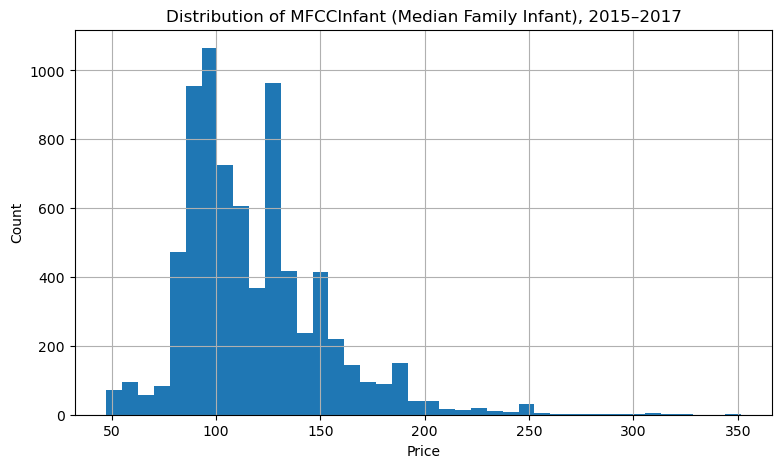

In [25]:
## Show what costs look like

import matplotlib.pyplot as plt

s = df_trend[flagship_price].dropna()
plt.figure()
plt.hist(s, bins=40)
plt.title(f"Distribution of {flagship_price} (Median Family Infant), {min(trend_years)}–{max(trend_years)}")
plt.xlabel("Price"); plt.ylabel("Count")
plt.show()

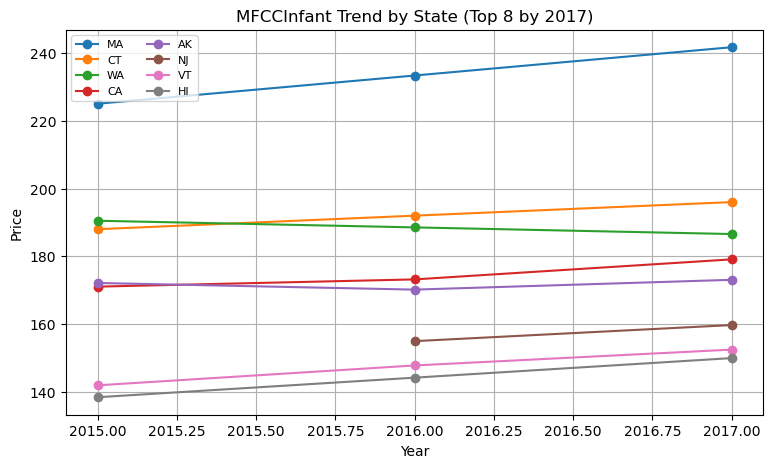

In [27]:
##State trends (top states by latest year)

# State-year medians
state_year = (df_trend.groupby(["State_Abbreviation","StudyYear"], as_index=False)[flagship_price]
              .median())

# Pick top-8 by latest year median (2017)
latest = state_year[state_year["StudyYear"]==max(trend_years)].copy()
top_states = (latest.sort_values(flagship_price, ascending=False)
                     .head(8)["State_Abbreviation"].tolist())

# Plot trend lines for those states
plt.figure()
for st in top_states:
    d = state_year[state_year["State_Abbreviation"]==st].sort_values("StudyYear")
    plt.plot(d["StudyYear"], d[flagship_price], marker="o", label=st)
plt.title(f"{flagship_price} Trend by State (Top 8 by 2017)")
plt.xlabel("Year"); plt.ylabel("Price"); plt.legend(ncol=2, fontsize=8)
plt.show()

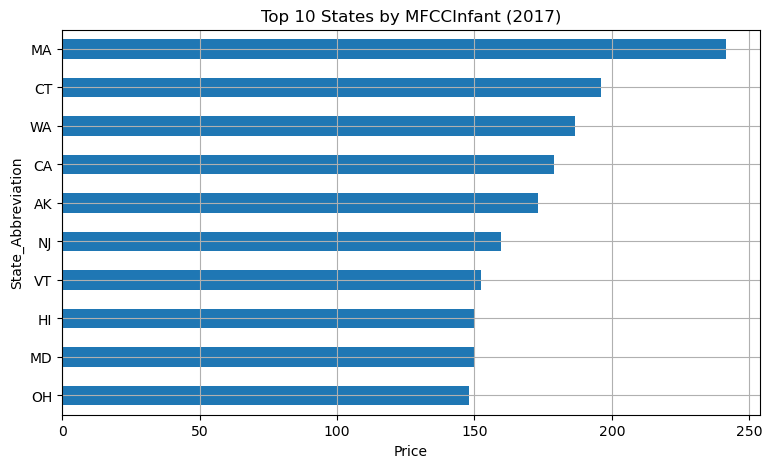

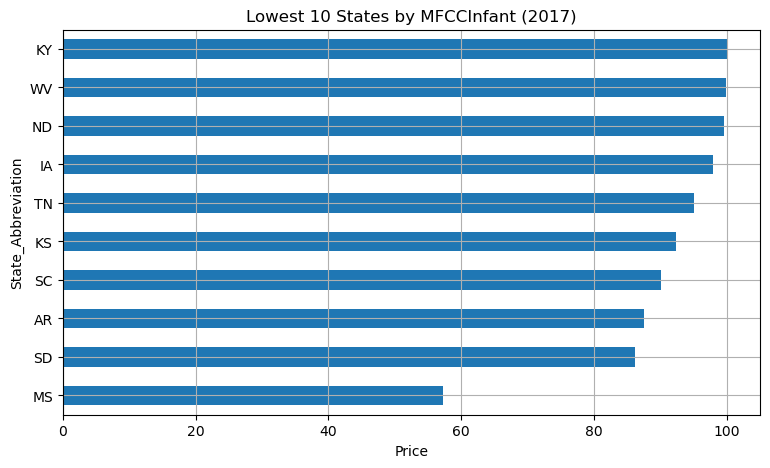

In [39]:
##Top/Bottom States
#Rebuild clean state medians for 2017
rank_2017 = (df[df["StudyYear"]==2017][["State_Abbreviation", flagship_price]]
             .dropna()
             .groupby("State_Abbreviation", as_index=False)
             .median())

# Top 10 expensive
top10 = rank_2017.nlargest(10, flagship_price)
plt.figure()
(top10.sort_values(flagship_price)
      .set_index("State_Abbreviation")[flagship_price]
      .plot(kind="barh"))
plt.title(f"Top 10 States by {flagship_price} (2017)")
plt.xlabel("Price")
plt.show()

# Bottom 10 (now works)
bottom10 = rank_2017.nsmallest(10, flagship_price)
plt.figure()
(bottom10.sort_values(flagship_price)
        .set_index("State_Abbreviation")[flagship_price]
        .plot(kind="barh"))
plt.title(f"Lowest 10 States by {flagship_price} (2017)")
plt.xlabel("Price")
plt.show()

Chosen income column: MHI


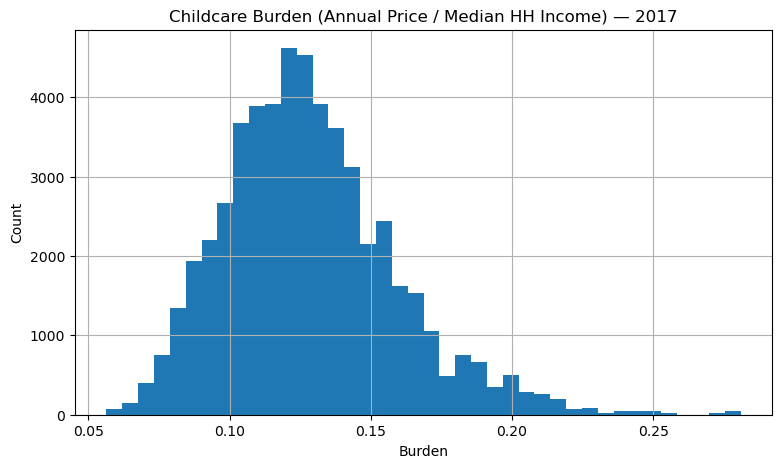

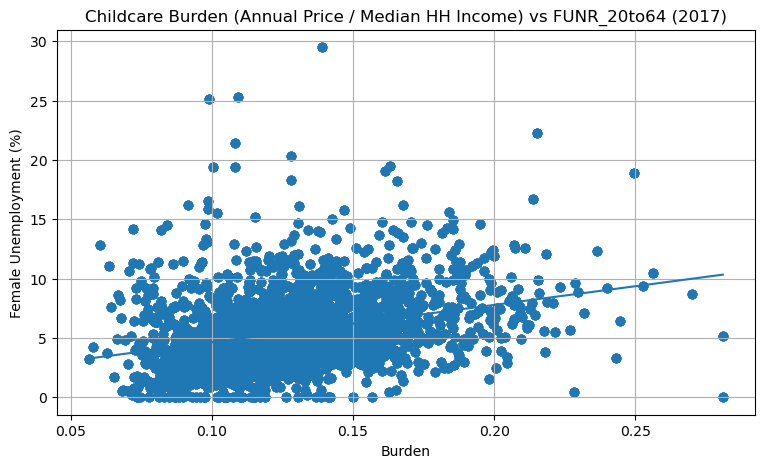

Slope: 31.4928


In [57]:

# 0) Clean out any previous income columns on df (safe to run multiple times)
to_drop = [c for c in df.columns if re.match(r'^(MHI|iMHI)|^income$', c, flags=re.I)]
df = df.drop(columns=to_drop, errors="ignore")

# 1) Pick an income column from the full data table (prefer year-specific)
inc_candidates = [c for c in data.columns if re.search(r"(income|median[_ ]?household|^MHI|^iMHI)", c, flags=re.I)]
preferred = ["MHI", "iMHI", "MHI_2018", "iMHI_2018"] + inc_candidates
income_col = next((c for c in preferred if c in data.columns), None)
print("Chosen income column:", income_col)

if income_col is None:
    raise ValueError("No income column found. Check the codebook for income fields.")

# 2) Build the small attach DF and rename the column to 'income'
if income_col.endswith("_2018"):
    attach = (data[["County_FIPS_Code", income_col]]
              .drop_duplicates()
              .rename(columns={income_col: "income"}))
    on_keys = ["County_FIPS_Code"]
else:
    attach = (data[["County_FIPS_Code", "StudyYear", income_col]]
              .drop_duplicates()
              .rename(columns={income_col: "income"}))
    on_keys = ["County_FIPS_Code", "StudyYear"]

# 3) Make sure join keys are the same dtype
for k in on_keys:
    if k == "County_FIPS_Code":
        df[k] = df[k].astype(str)
        attach[k] = attach[k].astype(str)

# 4) Merge cleanly (no suffix collisions now)
df = df.merge(attach, on=on_keys, how="left")

# 5) Optional fallback: if we used year-specific and still have gaps, fill from static 2018 if available
if "income" in df.columns and not income_col.endswith("_2018"):
    for static_col in ["MHI_2018", "iMHI_2018"]:
        if static_col in data.columns:
            fallback = data[["County_FIPS_Code", static_col]].drop_duplicates()
            fallback["County_FIPS_Code"] = fallback["County_FIPS_Code"].astype(str)
            df = df.merge(fallback, on="County_FIPS_Code", how="left")
            df["income"] = df["income"].fillna(df[static_col])
            df = df.drop(columns=[static_col])



# Build burden for 2017
base17 = df[df["StudyYear"] == 2017].dropna(subset=[flagship_price, "income"]).copy()

base17["annual_price"] = base17[flagship_price] * 52  # if weekly; still fine as a comparable index
base17["burden"] = base17["annual_price"] / base17["income"]
burden_label = "Childcare Burden (Annual Price / Median HH Income)"

import numpy as np, matplotlib.pyplot as plt
plt.figure()
base17["burden"].hist(bins=40)
plt.title(burden_label + " — 2017")
plt.xlabel("Burden"); plt.ylabel("Count"); plt.show()

# (Optional) burden vs female unemployment
if "FUNR_20to64" in base17.columns:
    d = base17.dropna(subset=["burden","FUNR_20to64"])
    x, y = d["burden"].values, d["FUNR_20to64"].values
    coef = np.polyfit(x, y, 1); line = np.poly1d(coef)
    xs = np.linspace(x.min(), x.max(), 100)
    plt.figure(); plt.scatter(x, y, alpha=0.25); plt.plot(xs, line(xs))
    plt.title(f"{burden_label} vs FUNR_20to64 (2017)")
    plt.xlabel("Burden"); plt.ylabel("Female Unemployment (%)"); plt.show()
    print("Slope:", round(coef[0], 4))

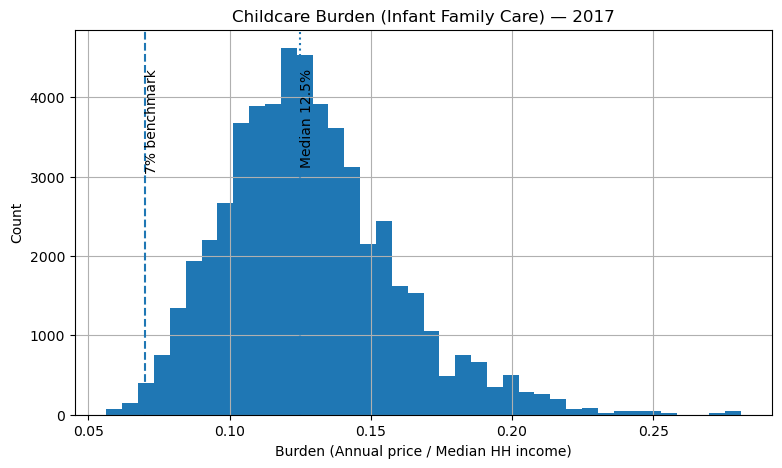

Share of counties above 7%: 99.4%


In [67]:
# Visualize Affordability

import numpy as np, matplotlib.pyplot as plt

AFFORD = 0.07  # 7% benchmark (see reference for this benchmark in the reference section below)
b = base17["burden"].dropna()
share_above = (b > AFFORD).mean()
median_burden = b.median()

plt.figure()
plt.hist(b, bins=40)
plt.axvline(AFFORD, linestyle="--")
plt.axvline(median_burden, linestyle=":")
plt.title("Childcare Burden (Infant Family Care) — 2017")
plt.xlabel("Burden (Annual price / Median HH income)"); plt.ylabel("Count")
plt.text(AFFORD, plt.ylim()[1]*0.9, "7% benchmark", rotation=90, va="top")
plt.text(median_burden, plt.ylim()[1]*0.9, f"Median {median_burden*100:.1f}%", rotation=90, va="top")
plt.show()

print(f"Share of counties above 7%: {share_above*100:.1f}%")

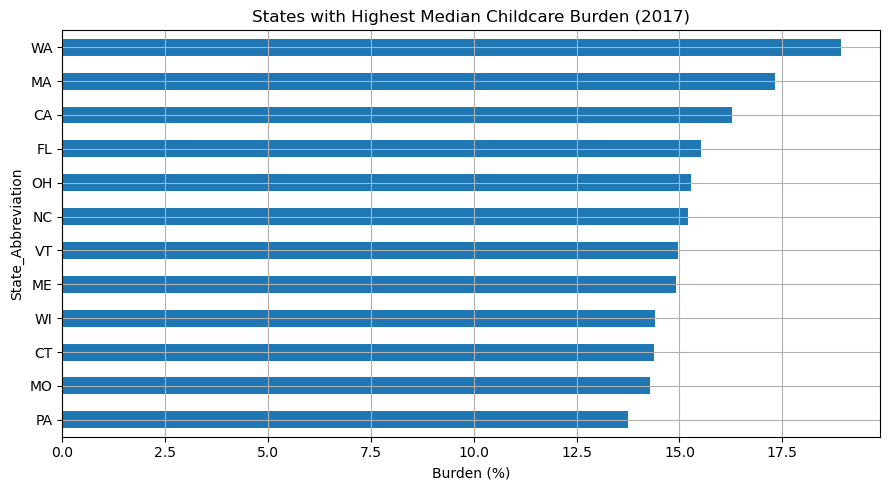

In [70]:
state_burden = (base17.groupby("State_Abbreviation", as_index=False)
                .agg(median_burden=("burden","median"),
                     p75_burden=("burden", lambda s: s.quantile(0.75)),
                     n=("burden","size"))
                .sort_values("median_burden", ascending=False))

plt.figure()
(state_burden.head(12).sort_values("median_burden")
 .set_index("State_Abbreviation")["median_burden"]
 .mul(100).plot(kind="barh"))
plt.title("States with Highest Median Childcare Burden (2017)")
plt.xlabel("Burden (%)"); plt.tight_layout(); plt.show()


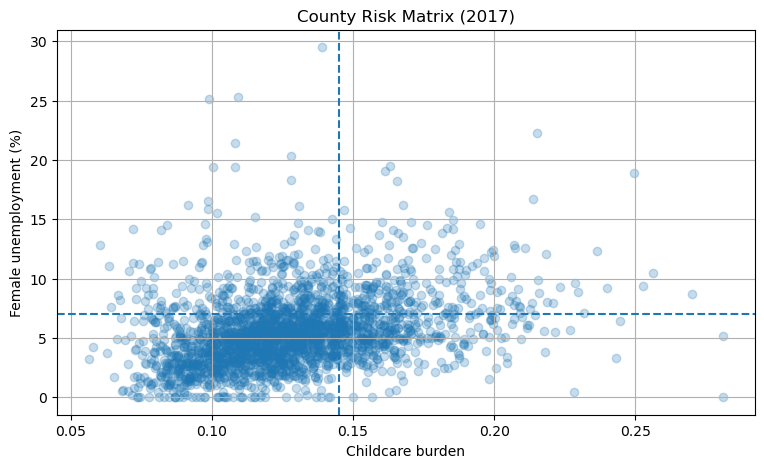

High-burden & High-unemployment counties: 250


In [72]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

# Build a clean county table for 2017
cols = ["County_FIPS_Code","County_Name","State_Abbreviation","burden"]
if "FUNR_20to64" in base17.columns:
    cols.append("FUNR_20to64")
county17 = (base17[cols]
            .dropna(subset=["burden"])
            .groupby(["County_FIPS_Code","County_Name","State_Abbreviation"], as_index=False)
            .median())

# Thresholds (75th percentiles – tune as needed)
b_thr = county17["burden"].quantile(0.75)
u_thr = county17["FUNR_20to64"].quantile(0.75) if "FUNR_20to64" in county17.columns else None

plt.figure()
plt.scatter(county17["burden"], county17.get("FUNR_20to64", pd.Series([np.nan]*len(county17))), alpha=0.25)
if u_thr is not None:
    plt.axhline(u_thr, linestyle="--")
plt.axvline(b_thr, linestyle="--")
plt.title("County Risk Matrix (2017)")
plt.xlabel("Childcare burden"); plt.ylabel("Female unemployment (%)")
plt.show()

# High-High quadrant list (your pilot candidates)
if u_thr is not None:
    hi_hi = county17[(county17["burden"]>=b_thr) & (county17["FUNR_20to64"]>=u_thr)]
    print("High-burden & High-unemployment counties:", len(hi_hi))
    hi_hi.sort_values("burden", ascending=False).head(15)[
        ["State_Abbreviation","County_Name","burden","FUNR_20to64"]
    ].to_csv("pilot_candidates_quadrant.csv", index=False)

In [74]:
# Top county per state by burden (ensures geographic spread)
top1_per_state = (county17.sort_values("burden", ascending=False)
                  .groupby("State_Abbreviation").head(1)
                  [["State_Abbreviation","County_Name","burden"]])

# If you want unemployment in the table too (when available)
if "FUNR_20to64" in county17.columns:
    top1_per_state = (county17.sort_values(["burden","FUNR_20to64"], ascending=False)
                      .groupby("State_Abbreviation").head(1)
                      [["State_Abbreviation","County_Name","burden","FUNR_20to64"]])

# Pretty print / export for slides
top1_pretty = top1_per_state.copy()
top1_pretty["burden"] = (top1_pretty["burden"]*100).round(1)
if "FUNR_20to64" in top1_pretty.columns:
    top1_pretty["FUNR_20to64"] = top1_pretty["FUNR_20to64"].round(1)

top1_pretty.sort_values("burden", ascending=False).head(20).to_csv("exec_target_list.csv", index=False)
print(top1_pretty.head(10))

     State_Abbreviation          County_Name  burden  FUNR_20to64
1695                 TX        Brooks County    28.1          5.2
562                  KY      McCreary County    27.0          8.7
1467                 SC     Allendale County    25.6         10.5
1448                 PA  Philadelphia County    25.3          9.4
2147                 VA         Emporia city    25.0         18.9
2311                 WI     Milwaukee County    24.5          6.4
2201                 WA       Pacific County    24.3          3.3
2362                 WY         Teton County    22.8          0.4
106                  FL       Madison County    22.1          7.9
2418                 CA       Trinity County    21.9          8.0


Program cost: $600,000
Savings:      $487,500
Net:          $-112,500
Break-even retention: 18.5%
Max stipend at 15% retention: $2,438


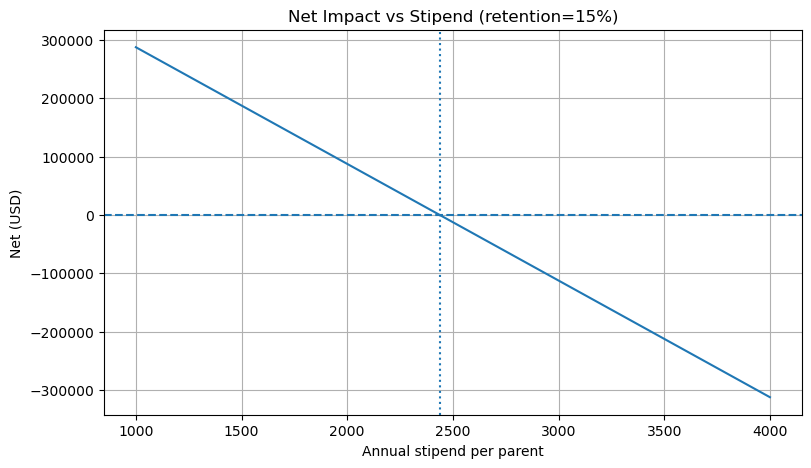

In [82]:
# Simple ROI calculator (edit these to match the employer)
parents = 200       # employees who would use the benefit
salary = 65000
turnover_cost_pct = 0.25     # replacement cost as % salary
stipend = 3000               # proposed annual stipend per parent
retention_gain = 0.15  # +15% fewer parent separations
utilization = 1.0         # share of eligible parents who use it
tax_credit = 0.0          # e.g., 0.2 if a 20% credit offsets employer cost

turnover_cost_per_parent = turnover_cost_pct * salary
program_cost = parents * utilization * stipend * (1 - tax_credit)
savings = parents * utilization * retention_gain * turnover_cost_per_parent
breakeven_retention = program_cost / (parents * utilization * turnover_cost_per_parent)
breakeven_stipend = retention_gain * turnover_cost_per_parent

print(f"Program cost: ${program_cost:,.0f}")
print(f"Savings:      ${savings:,.0f}")
print(f"Net:          ${savings - program_cost:,.0f}")
print(f"Break-even retention: {breakeven_retention*100:.1f}%")
print(f"Max stipend at {retention_gain*100:.0f}% retention: ${breakeven_stipend:,.0f}")

import numpy as np, matplotlib.pyplot as plt
stipends = np.arange(1000, 4001, 100)
net = parents*utilization*retention_gain*turnover_cost_per_parent - parents*utilization*stipends*(1-tax_credit)
plt.figure(); plt.plot(stipends, net); plt.axhline(0, linestyle="--")
plt.axvline(breakeven_stipend, linestyle=":"); 
plt.title(f"Net Impact vs Stipend (retention={retention_gain*100:.0f}%)")
plt.xlabel("Annual stipend per parent"); plt.ylabel("Net (USD)"); plt.show()

## References  

https://www.americanprogress.org/article/fact-sheet-what-to-know-about-the-child-care-for-working-families-act/